In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plot


In [2]:


#Cleaning and format changing
df=pd.read_csv("retail_sales_dataset.csv")
df.drop_duplicates(inplace=True)
df["Date"]=pd.to_datetime(df["Date"])
df.dropna(inplace=True)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB
None


In [3]:

#Profit Analysis
stats=df["Total Amount"].describe()
print(stats)



count    1000.000000
mean      456.000000
std       559.997632
min        25.000000
25%        60.000000
50%       135.000000
75%       900.000000
max      2000.000000
Name: Total Amount, dtype: float64


In [4]:
#Most popular product Category
mostpopular=df["Product Category"].mode()[0]
print(f"Most Favourite Product category According to buys is in {mostpopular}")


Most Favourite Product category According to buys is in Clothing


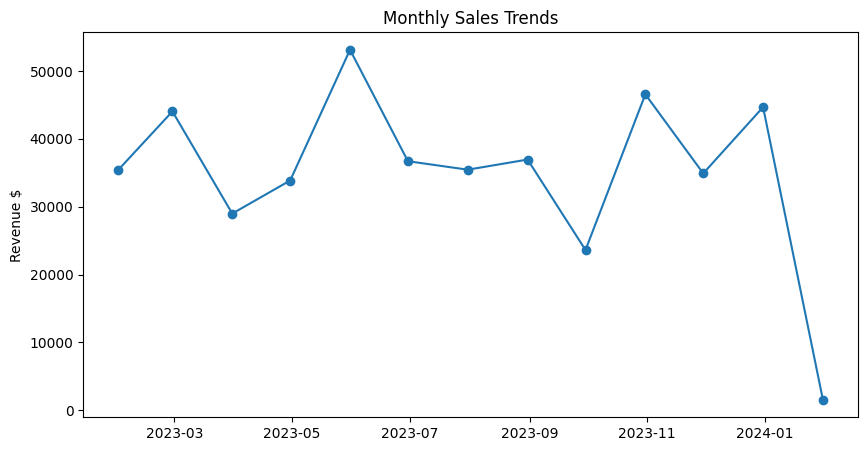

In [5]:
#Indexing for Efficient slicing
df.set_index("Date",inplace=True)

#aggregating data according to month
monthlysales=df["Total Amount"].resample("ME").sum()




#Revenue vs Month Trend Chart
plot.figure(figsize=(10,5))  #trends chart size
plot.plot(monthlysales,marker="o",linestyle="-") 
plot.title("Monthly Sales Trends")
plot.ylabel("Revenue $") #vertical line name
plot.show() # showtrends 



<function matplotlib.pyplot.show(close=None, block=None)>

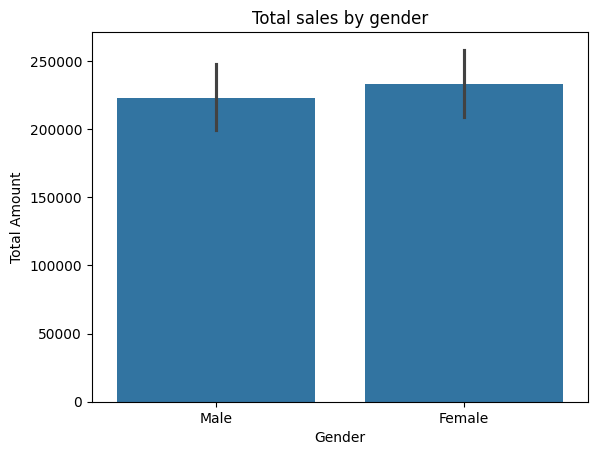

In [6]:
sb.barplot(x="Gender",y="Total Amount",data=df,estimator=sum)
plot.title("Total sales by gender")
plot.show

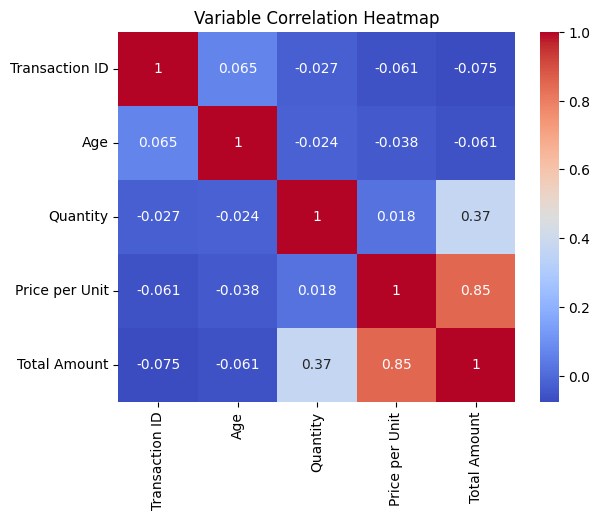

In [9]:
# 1. Calculate correlation ONLY for numeric columns
correlation_matrix = df.corr(numeric_only=True)

# 2. Pass that specific matrix to the heatmap
sb.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plot.title('Variable Correlation Heatmap')
plot.show()
